# Model Building

[OK] Dataset loaded! Shape: (25000, 37)
[OK] Feature engineering done!
[OK] NaN cleanup done. Remaining NaNs: 0
[OK] Using 34 features

[PREP] Preparing Model A (Binary)...
  X shape: (25000, 34) | NaNs: 0
[PREP] Preparing Model B (Multi-class)...
  X shape: (25000, 34) | NaNs: 0

[SPLIT]  Splitting and scaling...
   Model A → Train: 20000, Test: 5000
   Model B → Train: 20000, Test: 5000

   MODEL A — BINARY (Delayed vs On-Time)
[RF] Training Random Forest (A)...
[LR] Training Logistic Regression (A)...
[DT] Training Decision Tree (A)...
[KNN] Training KNN (A)...
[OK] All Model A classifiers trained!

[RF] RANDOM FOREST
Accuracy: 88.24% | AUC: 0.9664 | PR-AUC: 0.9091 | F1: 0.8131
              precision    recall  f1-score   support

     On-Time       0.98      0.85      0.91      3666
     Delayed       0.71      0.96      0.81      1334

    accuracy                           0.88      5000
   macro avg       0.84      0.91      0.86      5000
weighted avg       0.91      0.88     

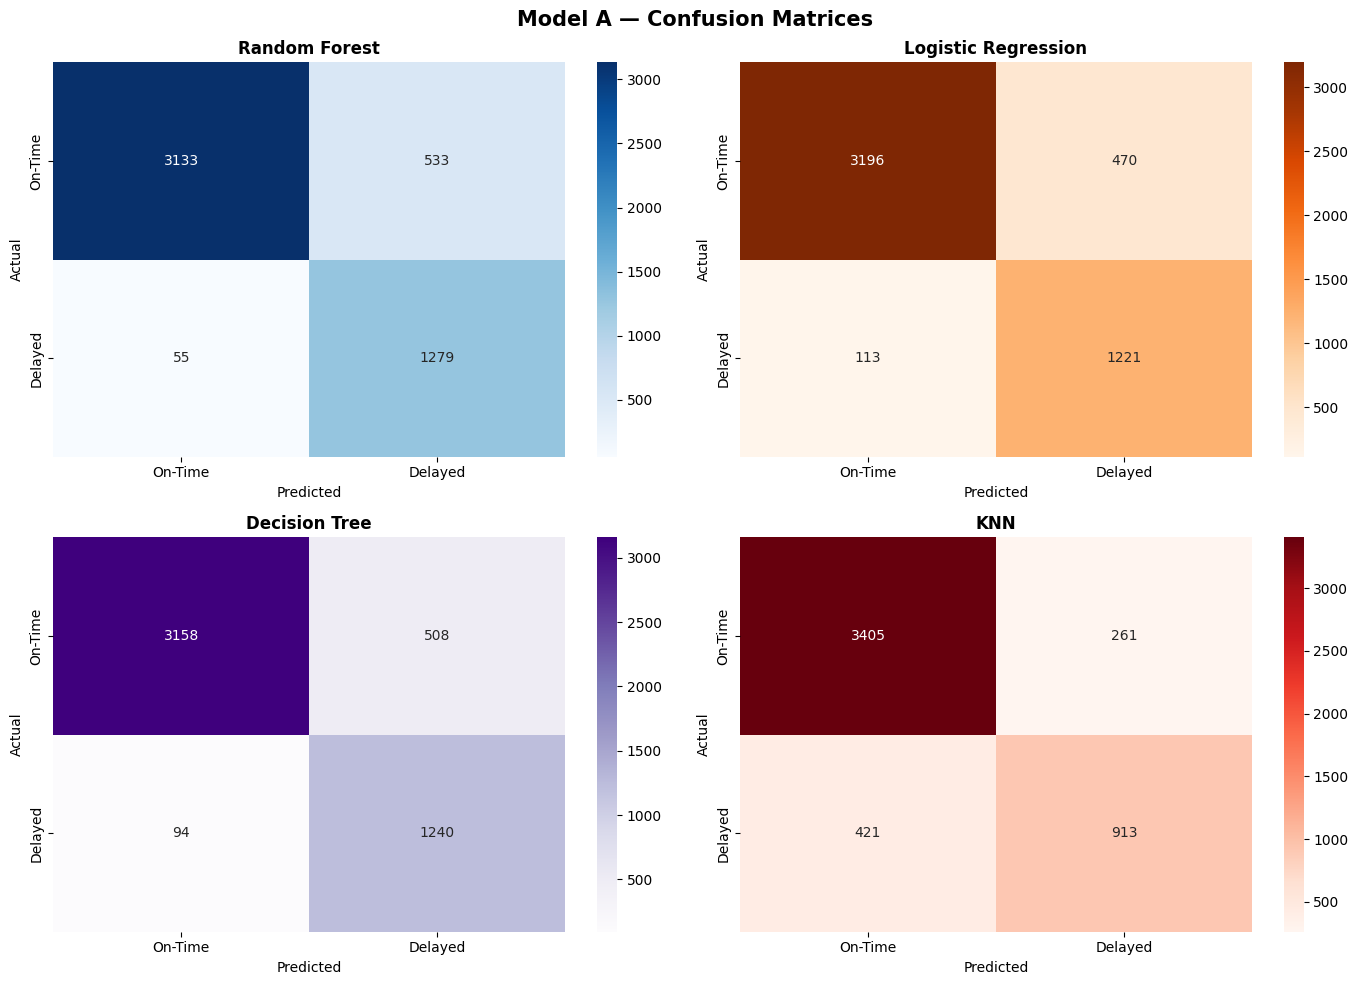

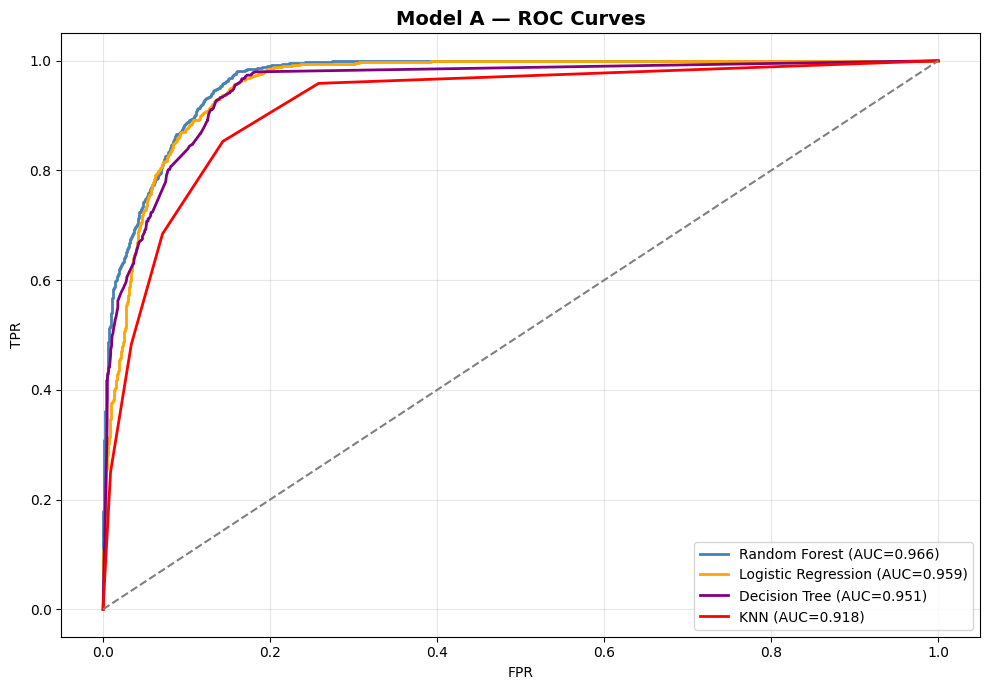

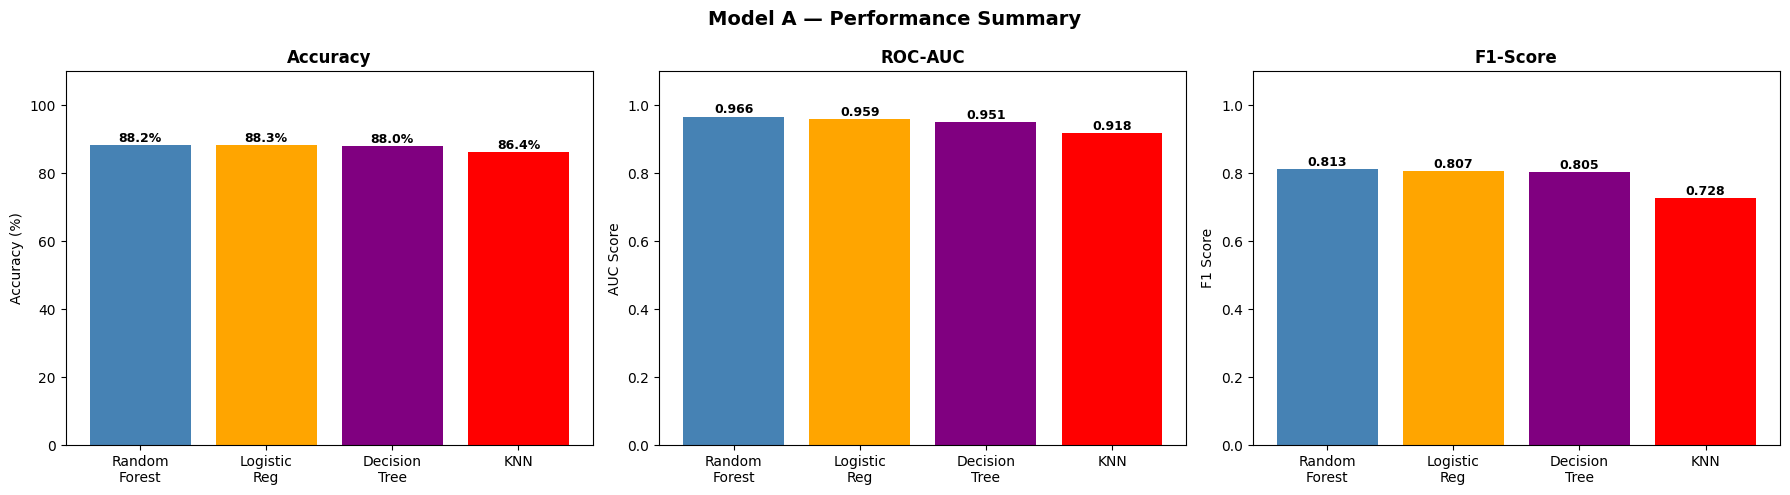

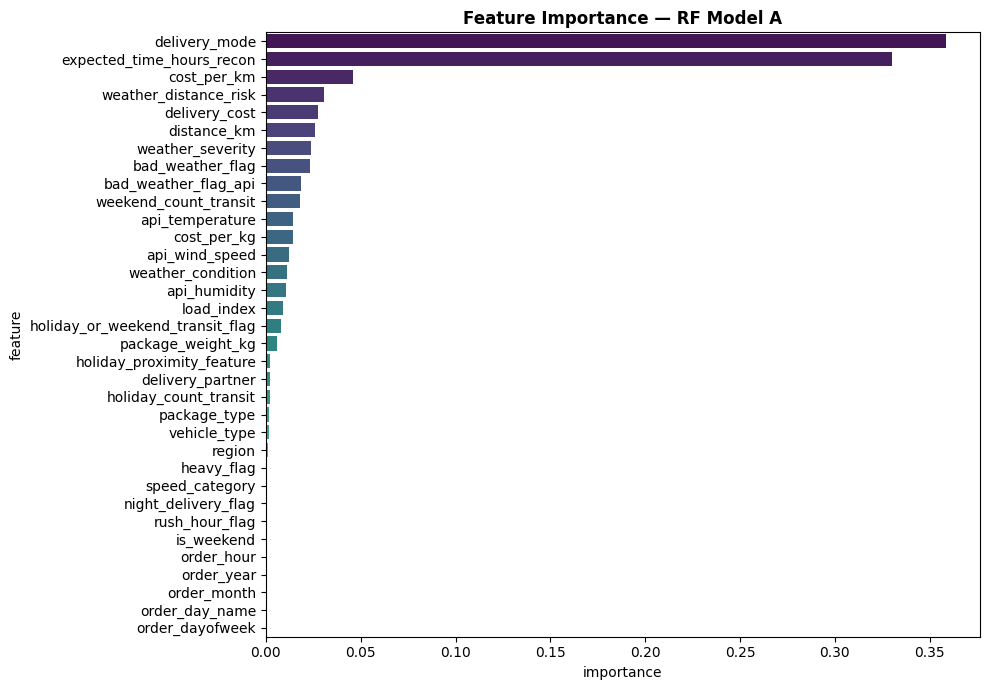


[RESULT] MODEL A — FINAL COMPARISON
              Model Accuracy (%) ROC-AUC F1-Score PR-AUC
      Random Forest        88.24  0.9664   0.8131 0.9091
Logistic Regression        88.34  0.9585   0.8073 0.8751
      Decision Tree        87.96  0.9512   0.8047 0.8717
                KNN        86.36  0.9180   0.7281 0.7667

[BEST] Best by AUC: Random Forest (0.9664)

   MODEL B — MULTI-CLASS (delivery_status)
Classes: ['delayed', 'delivered', 'failed']
[RF] Training Random Forest (B)...
[LR] Training Logistic Regression (B)...
[DT] Training Decision Tree (B)...
[KNN] Training KNN (B)...
[OK] All Model B classifiers trained!

[RF] RANDOM FOREST
Accuracy: 80.88% | Macro F1: 0.5700

[LR] LOGISTIC REGRESSION
Accuracy: 77.20% | Macro F1: 0.5596

[DT] DECISION TREE
Accuracy: 77.10% | Macro F1: 0.5645

[KNN] KNN
Accuracy: 84.34% | Macro F1: 0.5415


In [1]:
# ============================================================
# ETA DELAY PREDICTION — FULL MODEL BUILDING SCRIPT
# Classification (Binary + Multi-class) + Regression
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score,
    f1_score, mean_absolute_error, mean_squared_error, r2_score
)

# ============================================================
# STEP 1: LOAD DATASET
# ============================================================
df = pd.read_csv("../Data/dataset_with_weather_features.csv")
print(f"[OK] Dataset loaded! Shape: {df.shape}")

# ============================================================
# STEP 2: FEATURE ENGINEERING
# ============================================================

# Parse timestamps
df["order_ts_recon"]    = pd.to_datetime(df["order_ts_recon"],    format="%d-%m-%Y %H.%M", errors="coerce")
df["expected_ts_recon"] = pd.to_datetime(df["expected_ts_recon"], format="%d-%m-%Y %H.%M", errors="coerce")
df["delivery_ts_recon"] = pd.to_datetime(df["delivery_ts_recon"], errors="coerce")

# Time features
df["order_dayofweek"]     = df["order_ts_recon"].dt.dayofweek.fillna(0).astype(int)
df["order_day_name"]      = df["order_ts_recon"].dt.day_name().fillna("Unknown")
df["order_month"]         = df["order_ts_recon"].dt.month.fillna(1).astype(int)
df["order_year"]          = df["order_ts_recon"].dt.year.fillna(2023).astype(int)
df["order_hour"]          = df["order_ts_recon"].dt.hour.fillna(0).astype(int)

# Behavioral flags
df["is_weekend"]          = (df["order_dayofweek"] >= 5).astype(int)
df["rush_hour_flag"]      = df["order_hour"].isin([8,9,10,17,18,19]).astype(int)
df["night_delivery_flag"] = df["order_hour"].isin(list(range(0,6)) + list(range(22,24))).astype(int)

# Speed category
df["speed_kmph_recon"] = df["speed_kmph_recon"].fillna(df["speed_kmph_recon"].median())
df["speed_category"]   = pd.cut(
    df["speed_kmph_recon"],
    bins=[0, 20, 40, 60, 100],
    labels=["Slow", "Medium", "Fast", "Very Fast"]
).astype(str).replace("nan", "Medium")

# Cost features
df["distance_km"]       = df["distance_km"].replace(0, np.nan).fillna(df["distance_km"].median())
df["package_weight_kg"] = df["package_weight_kg"].replace(0, np.nan).fillna(df["package_weight_kg"].median())
df["cost_per_km"]       = (df["delivery_cost"] / df["distance_km"]).fillna(0)
df["cost_per_kg"]       = (df["delivery_cost"] / df["package_weight_kg"]).fillna(0)
df["heavy_flag"]        = (df["package_weight_kg"] > 30).astype(int)

# Weather features
df["weather_condition"]     = df["weather_condition"].fillna("clear")
df["bad_weather_flag"]      = df["weather_condition"].isin(["rainy","stormy","foggy"]).astype(int)
weather_map                 = {"clear":0,"cloudy":1,"hot":1,"cold":1,"rainy":2,"foggy":3,"stormy":4}
df["weather_severity"]      = df["weather_condition"].map(weather_map).fillna(0).astype(int)
df["weather_distance_risk"] = df["weather_severity"] * df["distance_km"]

# Load index
df["load_index"] = df["package_weight_kg"] * df["distance_km"]

# Partner/region/vehicle delay rates
df["delayed"] = df["delayed"].fillna("no")
df["partner_delay_rate"] = df.groupby("delivery_partner")["delayed"].transform(lambda x: (x=="yes").mean())
df["region_delay_rate"]  = df.groupby("region")["delayed"].transform(lambda x: (x=="yes").mean())
df["vehicle_delay_rate"] = df.groupby("vehicle_type")["delayed"].transform(lambda x: (x=="yes").mean())

print("[OK] Feature engineering done!")

# ============================================================
# NUCLEAR NaN CLEANUP
# ============================================================
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        mode_val = df[col].mode()
        df[col] = df[col].fillna(mode_val[0] if len(mode_val) > 0 else "Unknown")

print(f"[OK] NaN cleanup done. Remaining NaNs: {df.isnull().sum().sum()}")

# ============================================================
# STEP 3: DEFINE SAFE FEATURES
# ============================================================
SAFE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag', 'speed_category',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
    'api_temperature', 'api_humidity', 'api_wind_speed', 'bad_weather_flag_api',
    'holiday_count_transit', 'weekend_count_transit',
    'holiday_or_weekend_transit_flag', 'holiday_proximity_feature',
]
SAFE_FEATURES = [f for f in SAFE_FEATURES if f in df.columns]
print(f"[OK] Using {len(SAFE_FEATURES)} features")

# ============================================================
# STEP 4: ENCODE + IMPUTE FUNCTION
# ============================================================
def prepare_xy(df, features, target_series):
    X = df[features].copy()
    encoders = {}
    for col in X.select_dtypes(include=['object','category']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        encoders[col] = le
    X = X.apply(pd.to_numeric, errors='coerce')
    X = X.fillna(X.median()).fillna(0)
    y = target_series.copy()
    print(f"  X shape: {X.shape} | NaNs: {X.isnull().sum().sum()}")
    return X, y, encoders

print("\n[PREP] Preparing Model A (Binary)...")
X_A, y_A, encoders_A = prepare_xy(df, SAFE_FEATURES, (df['delayed']=='yes').astype(int))

print("[PREP] Preparing Model B (Multi-class)...")
X_B, y_B, encoders_B = prepare_xy(df, SAFE_FEATURES, df['delivery_status'])

# ============================================================
# STEP 5: SPLIT + SCALE
# ============================================================
def split_and_scale(X, y, stratify=True):
    strat = y if stratify else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=strat)
    scaler = StandardScaler()
    X_train_sc = np.nan_to_num(scaler.fit_transform(X_train), nan=0.0)
    X_test_sc  = np.nan_to_num(scaler.transform(X_test),      nan=0.0)
    return X_train_sc, X_test_sc, y_train, y_test, scaler

print("\n[SPLIT]  Splitting and scaling...")
X_train_A, X_test_A, y_train_A, y_test_A, scaler_A = split_and_scale(X_A, y_A)
X_train_B, X_test_B, y_train_B, y_test_B, scaler_B = split_and_scale(X_B, y_B)
print(f"   Model A → Train: {len(y_train_A)}, Test: {len(y_test_A)}")
print(f"   Model B → Train: {len(y_train_B)}, Test: {len(y_test_B)}")

# ============================================================
# MODEL A — BINARY CLASSIFICATION
# ============================================================
print("\n" + "="*60)
print("   MODEL A — BINARY (Delayed vs On-Time)")
print("="*60)

print("[RF] Training Random Forest (A)...")
rf_A = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20,
                               min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight='balanced')
rf_A.fit(X_train_A, y_train_A)

print("[LR] Training Logistic Regression (A)...")
lr_A = LogisticRegression(max_iter=1000, random_state=42, C=1.0, class_weight='balanced')
lr_A.fit(X_train_A, y_train_A)

print("[DT] Training Decision Tree (A)...")
dt_A = DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                               min_samples_leaf=10, random_state=42, class_weight='balanced')
dt_A.fit(X_train_A, y_train_A)

print("[KNN] Training KNN (A)...")
knn_A = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_A.fit(X_train_A, y_train_A)
print("[OK] All Model A classifiers trained!")

y_pred_rf_A  = rf_A.predict(X_test_A);   y_proba_rf_A  = rf_A.predict_proba(X_test_A)[:,1]
y_pred_lr_A  = lr_A.predict(X_test_A);   y_proba_lr_A  = lr_A.predict_proba(X_test_A)[:,1]
y_pred_dt_A  = dt_A.predict(X_test_A);   y_proba_dt_A  = dt_A.predict_proba(X_test_A)[:,1]
y_pred_knn_A = knn_A.predict(X_test_A);  y_proba_knn_A = knn_A.predict_proba(X_test_A)[:,1]

rf_acc_A  = accuracy_score(y_test_A, y_pred_rf_A);   rf_auc_A  = roc_auc_score(y_test_A, y_proba_rf_A)
lr_acc_A  = accuracy_score(y_test_A, y_pred_lr_A);   lr_auc_A  = roc_auc_score(y_test_A, y_proba_lr_A)
dt_acc_A  = accuracy_score(y_test_A, y_pred_dt_A);   dt_auc_A  = roc_auc_score(y_test_A, y_proba_dt_A)
knn_acc_A = accuracy_score(y_test_A, y_pred_knn_A);  knn_auc_A = roc_auc_score(y_test_A, y_proba_knn_A)

rf_f1_A   = f1_score(y_test_A, y_pred_rf_A);   rf_prauc_A  = average_precision_score(y_test_A, y_proba_rf_A)
lr_f1_A   = f1_score(y_test_A, y_pred_lr_A);   lr_prauc_A  = average_precision_score(y_test_A, y_proba_lr_A)
dt_f1_A   = f1_score(y_test_A, y_pred_dt_A);   dt_prauc_A  = average_precision_score(y_test_A, y_proba_dt_A)
knn_f1_A  = f1_score(y_test_A, y_pred_knn_A);  knn_prauc_A = average_precision_score(y_test_A, y_proba_knn_A)

for name, acc, auc, f1v, prauc, y_pred in [
    ("[RF] RANDOM FOREST",       rf_acc_A,  rf_auc_A,  rf_f1_A,  rf_prauc_A,  y_pred_rf_A),
    ("[LR] LOGISTIC REGRESSION", lr_acc_A,  lr_auc_A,  lr_f1_A,  lr_prauc_A,  y_pred_lr_A),
    ("[DT] DECISION TREE",       dt_acc_A,  dt_auc_A,  dt_f1_A,  dt_prauc_A,  y_pred_dt_A),
    ("[KNN] KNN",                 knn_acc_A, knn_auc_A, knn_f1_A, knn_prauc_A, y_pred_knn_A),
]:
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(f"Accuracy: {acc*100:.2f}% | AUC: {auc:.4f} | PR-AUC: {prauc:.4f} | F1: {f1v:.4f}")
    print(classification_report(y_test_A, y_pred, target_names=['On-Time','Delayed']))

# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()
for i, (y_pred, title, cmap) in enumerate([
    (y_pred_rf_A,  'Random Forest',       'Blues'),
    (y_pred_lr_A,  'Logistic Regression', 'Oranges'),
    (y_pred_dt_A,  'Decision Tree',       'Purples'),
    (y_pred_knn_A, 'KNN',                 'Reds'),
]):
    cm = confusion_matrix(y_test_A, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['On-Time','Delayed'], yticklabels=['On-Time','Delayed'])
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_ylabel('Actual'); axes[i].set_xlabel('Predicted')
plt.suptitle('Model A — Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('model_A_confusion.png', dpi=120, bbox_inches='tight'); plt.show()

# ROC Curves
plt.figure(figsize=(10,7))
for y_proba, auc_val, label, color in [
    (y_proba_rf_A,  rf_auc_A,  'Random Forest',       'steelblue'),
    (y_proba_lr_A,  lr_auc_A,  'Logistic Regression', 'orange'),
    (y_proba_dt_A,  dt_auc_A,  'Decision Tree',       'purple'),
    (y_proba_knn_A, knn_auc_A, 'KNN',                 'red'),
]:
    fpr, tpr, _ = roc_curve(y_test_A, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc_val:.3f})', color=color)
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Model A — ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('model_A_roc.png', dpi=120, bbox_inches='tight'); plt.show()

# Comparison Chart
all_models_A = ['Random\nForest','Logistic\nReg','Decision\nTree','KNN']
all_acc_A    = [rf_acc_A*100, lr_acc_A*100, dt_acc_A*100, knn_acc_A*100]
all_auc_A    = [rf_auc_A, lr_auc_A, dt_auc_A, knn_auc_A]
all_f1_A     = [rf_f1_A, lr_f1_A, dt_f1_A, knn_f1_A]
colors_A     = ['steelblue','orange','purple','red']

fig, axes = plt.subplots(1,3, figsize=(18,5))
for ax, vals, title, ylabel, ylim, fmt in [
    (axes[0], all_acc_A, 'Accuracy',  'Accuracy (%)', 100, '{:.1f}%'),
    (axes[1], all_auc_A, 'ROC-AUC',  'AUC Score',      1, '{:.3f}'),
    (axes[2], all_f1_A,  'F1-Score', 'F1 Score',        1, '{:.3f}'),
]:
    ax.bar(all_models_A, vals, color=colors_A)
    ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel); ax.set_ylim([0, ylim*1.1])
    for i,v in enumerate(vals): ax.text(i, v*1.01, fmt.format(v), ha='center', fontsize=9, fontweight='bold')
plt.suptitle('Model A — Performance Summary', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('model_A_comparison.png', dpi=120, bbox_inches='tight'); plt.show()

# Feature Importance
feat_imp_A = pd.DataFrame({'feature': X_A.columns, 'importance': rf_A.feature_importances_}).sort_values('importance', ascending=False)
plt.figure(figsize=(10,7))
sns.barplot(data=feat_imp_A, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance — RF Model A', fontweight='bold'); plt.tight_layout()
plt.savefig('model_A_feat_importance.png', dpi=120, bbox_inches='tight'); plt.show()

# Summary
summary_A = pd.DataFrame({
    'Model':        ['Random Forest','Logistic Regression','Decision Tree','KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_acc_A],
    'ROC-AUC':      [f"{v:.4f}" for v in all_auc_A],
    'F1-Score':     [f"{v:.4f}" for v in all_f1_A],
    'PR-AUC':       [f"{v:.4f}" for v in [rf_prauc_A, lr_prauc_A, dt_prauc_A, knn_prauc_A]],
})
print("\n[RESULT] MODEL A — FINAL COMPARISON")
print("="*65); print(summary_A.to_string(index=False))
print(f"\n[BEST] Best by AUC: {summary_A['Model'][all_auc_A.index(max(all_auc_A))]} ({max(all_auc_A):.4f})")

# ============================================================
# MODEL B — MULTI-CLASS CLASSIFICATION
# ============================================================
print("\n" + "="*60)
print("   MODEL B — MULTI-CLASS (delivery_status)")
print("="*60)
print(f"Classes: {sorted(y_B.unique())}")

print("[RF] Training Random Forest (B)...")
rf_B = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20,
                               min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight='balanced')
rf_B.fit(X_train_B, y_train_B)

print("[LR] Training Logistic Regression (B)...")
lr_B = LogisticRegression(max_iter=2000, random_state=42, C=1.0, class_weight='balanced')
lr_B.fit(X_train_B, y_train_B)

print("[DT] Training Decision Tree (B)...")
dt_B = DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                               min_samples_leaf=10, random_state=42, class_weight='balanced')
dt_B.fit(X_train_B, y_train_B)

print("[KNN] Training KNN (B)...")
knn_B = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn_B.fit(X_train_B, y_train_B)
print("[OK] All Model B classifiers trained!")

y_pred_rf_B  = rf_B.predict(X_test_B)
y_pred_lr_B  = lr_B.predict(X_test_B)
y_pred_dt_B  = dt_B.predict(X_test_B)
y_pred_knn_B = knn_B.predict(X_test_B)

rf_acc_B  = accuracy_score(y_test_B, y_pred_rf_B);  rf_f1_B  = f1_score(y_test_B, y_pred_rf_B,  average='macro')
lr_acc_B  = accuracy_score(y_test_B, y_pred_lr_B);  lr_f1_B  = f1_score(y_test_B, y_pred_lr_B,  average='macro')
dt_acc_B  = accuracy_score(y_test_B, y_pred_dt_B);  dt_f1_B  = f1_score(y_test_B, y_pred_dt_B,  average='macro')
knn_acc_B = accuracy_score(y_test_B, y_pred_knn_B); knn_f1_B = f1_score(y_test_B, y_pred_knn_B, average='macro')

for name, acc, f1v, y_pred in [
    ("[RF] RANDOM FOREST",       rf_acc_B,  rf_f1_B,  y_pred_rf_B),
    ("[LR] LOGISTIC REGRESSION", lr_acc_B,  lr_f1_B,  y_pred_lr_B),
    ("[DT] DECISION TREE",       dt_acc_B,  dt_f1_B,  y_pred_dt_B),
    ("[KNN] KNN",                 knn_acc_B, knn_f1_B, y_pred_knn_B),
]:
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(f"Accuracy: {acc*100:.2f}% | Macro F1: {f1v:.4f}")


  BEFORE ENRICHMENT

[LOADED] ../Data/eta_feature_engineered_dataset.csv → shape: (25000, 54)
  Features used: 25

  Results — Before Enrichment
              Model  Accuracy (%)  ROC-AUC  PR-AUC  F1-Score  Precision  Recall
      Random Forest         88.30   0.9672  0.9117    0.8140     0.7068  0.9595
Logistic Regression         88.38   0.9586  0.8749    0.8084     0.7216  0.9190
      Decision Tree         87.28   0.9525  0.8741    0.7972     0.6937  0.9370
                KNN         87.44   0.9300  0.7976    0.7599     0.7754  0.7451

  AFTER ENRICHMENT

[LOADED] ../Data/dataset_with_weather_features.csv → shape: (25000, 37)
  Features used: 31

  Results — After Enrichment
              Model  Accuracy (%)  ROC-AUC  PR-AUC  F1-Score  Precision  Recall
      Random Forest         88.30   0.9667  0.9087    0.8141     0.7066  0.9603
Logistic Regression         88.40   0.9585  0.8752    0.8083     0.7228  0.9168
      Decision Tree         87.74   0.9492  0.8692    0.8033     0.7022

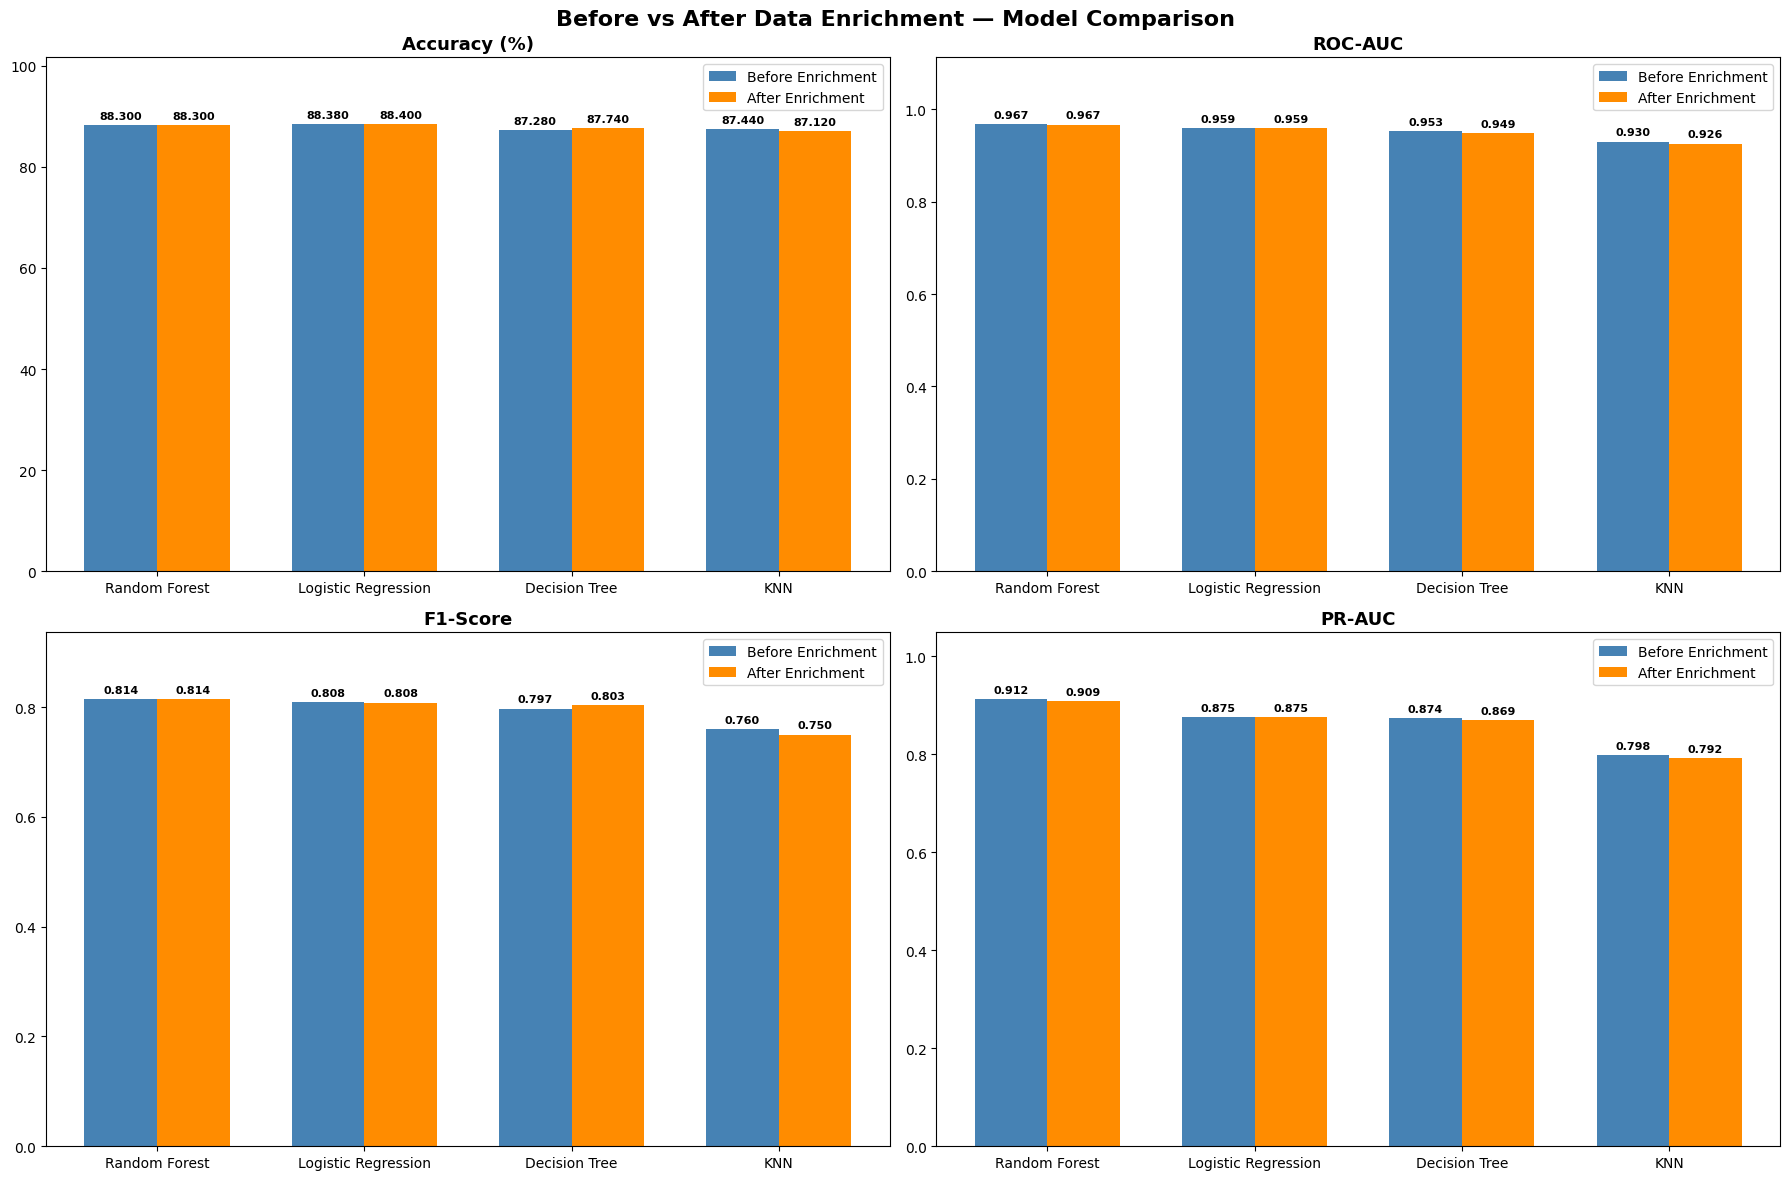


[SAVED] before_vs_after_comparison.png

  IMPROVEMENT AFTER ENRICHMENT (After - Before)
              Model  Accuracy (%)  ROC-AUC  PR-AUC  F1-Score
      Random Forest          0.00  -0.0005 -0.0030    0.0001
Logistic Regression          0.02  -0.0001  0.0003   -0.0001
      Decision Tree          0.46  -0.0033 -0.0049    0.0061
                KNN         -0.32  -0.0043 -0.0055   -0.0099

Best model BEFORE enrichment → Random Forest  (ROC-AUC: 0.9672)
Best model AFTER  enrichment → Random Forest  (ROC-AUC: 0.9667)
Overall AUC gain             → -0.0005


In [2]:
# ============================================================
# MODEL COMPARISON
# BEFORE Enrichment (eta_feature_engineered_dataset.csv)
# vs
# AFTER Enrichment  (dataset_with_weather_features.csv)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

# ============================================================
# SHARED SAFE FEATURES (before enrichment — Cell 95)
# ============================================================
BASE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
]

# Extra features added after enrichment (Cell 162)
ENRICHED_EXTRA = [
    'bad_weather_flag_api',
    'holiday_pressure', 'has_holiday_transit',
    'weekend_pressure',
    'holiday_or_weekend_transit_flag', 'holiday_proximity_feature',
]

# ============================================================
# HELPER: prepare a dataset
# ============================================================
def prepare_dataset(path, extra_features=[]):
    df = pd.read_csv(path)
    print(f"\n[LOADED] {path} → shape: {df.shape}")

    # Timestamps
    df["order_ts_recon"]    = pd.to_datetime(df["order_ts_recon"],    format="%d-%m-%Y %H.%M", errors="coerce")
    df["expected_ts_recon"] = pd.to_datetime(df["expected_ts_recon"], format="%d-%m-%Y %H.%M", errors="coerce")

    # Time features
    df["order_dayofweek"]     = df["order_ts_recon"].dt.dayofweek.fillna(0).astype(int)
    df["order_day_name"]      = df["order_ts_recon"].dt.day_name().fillna("Unknown")
    df["order_month"]         = df["order_ts_recon"].dt.month.fillna(1).astype(int)
    df["order_year"]          = df["order_ts_recon"].dt.year.fillna(2023).astype(int)
    df["order_hour"]          = df["order_ts_recon"].dt.hour.fillna(0).astype(int)
    df["is_weekend"]          = (df["order_dayofweek"] >= 5).astype(int)
    df["rush_hour_flag"]      = df["order_hour"].isin([8,9,10,17,18,19]).astype(int)
    df["night_delivery_flag"] = df["order_hour"].isin(list(range(0,6))+list(range(22,24))).astype(int)

    # Cost features
    df["distance_km"]       = df["distance_km"].replace(0, np.nan).fillna(df["distance_km"].median())
    df["package_weight_kg"] = df["package_weight_kg"].replace(0, np.nan).fillna(df["package_weight_kg"].median())
    df["cost_per_km"]       = (df["delivery_cost"] / df["distance_km"]).fillna(0)
    df["cost_per_kg"]       = (df["delivery_cost"] / df["package_weight_kg"]).fillna(0)
    df["heavy_flag"]        = (df["package_weight_kg"] > 30).astype(int)

    # Weather
    df["weather_condition"]     = df["weather_condition"].fillna("clear")
    df["bad_weather_flag"]      = df["weather_condition"].isin(["rainy","stormy","foggy"]).astype(int)
    weather_map                 = {"clear":0,"cloudy":1,"hot":1,"cold":1,"rainy":2,"foggy":3,"stormy":4}
    df["weather_severity"]      = df["weather_condition"].map(weather_map).fillna(0).astype(int)
    df["weather_distance_risk"] = df["weather_severity"] * df["distance_km"]
    df["load_index"]            = df["package_weight_kg"] * df["distance_km"]
    df["expected_time_hours_recon"] = df["expected_time_hours_recon"].replace(0, np.nan).fillna(
        df["expected_time_hours_recon"].median()
    )

    # Drop post-outcome / noise columns
    for col in ["speed_category","speed_kmph_recon","api_temperature","api_humidity","api_wind_speed"]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # Holiday features (enriched only)
    if "holiday_count_transit" in df.columns:
        df["holiday_count_transit"] = df["holiday_count_transit"].fillna(0)
        df["holiday_pressure"]      = df["holiday_count_transit"] / df["expected_time_hours_recon"]
        df["has_holiday_transit"]   = (df["holiday_count_transit"] > 0).astype(int)
    if "weekend_count_transit" in df.columns:
        df["weekend_count_transit"] = df["weekend_count_transit"].fillna(0)
        df["weekend_pressure"]      = df["weekend_count_transit"] / df["expected_time_hours_recon"]

    df["delayed"] = df["delayed"].fillna("no")

    # NaN cleanup
    for col in df.columns:
        if df[col].dtype in ['float64','int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            mode_val = df[col].mode()
            df[col]  = df[col].fillna(mode_val[0] if len(mode_val) > 0 else "Unknown")

    # Build feature list
    features = [f for f in BASE_FEATURES + extra_features if f in df.columns]
    print(f"  Features used: {len(features)}")

    # Encode
    X = df[features].copy()
    for col in X.select_dtypes(include=['object','category']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    y = (df['delayed'] == 'yes').astype(int)

    return df, X, y

# ============================================================
# HELPER: train/split/scale + add delay rate features
# ============================================================
def split_scale_rate(df, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Delay rate features — train only, no leakage
    global_rate = (df['delayed'] == 'yes').mean()
    for orig_col, rate_col in [
        ('delivery_partner','partner_delay_rate'),
        ('region',          'region_delay_rate'),
        ('vehicle_type',    'vehicle_delay_rate'),
    ]:
        rate_map = df.loc[y_train.index].groupby(orig_col)['delayed'].apply(lambda x: (x=='yes').mean())
        X_train[rate_col] = df.loc[y_train.index, orig_col].map(rate_map).fillna(global_rate).values
        X_test[rate_col]  = df.loc[y_test.index,  orig_col].map(rate_map).fillna(global_rate).values

    scaler = StandardScaler()
    X_train_sc = np.nan_to_num(scaler.fit_transform(X_train))
    X_test_sc  = np.nan_to_num(scaler.transform(X_test))

    return X_train_sc, X_test_sc, y_train, y_test

# ============================================================
# HELPER: train all 4 models + evaluate
# ============================================================
def train_and_evaluate(X_train, X_test, y_train, y_test, label):
    models = {
        "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight='balanced'),
        "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced'),
        "Decision Tree":       DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42, class_weight='balanced'),
        "KNN":                 KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    }

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1]
        results.append({
            "Model":        name,
            "Dataset":      label,
            "Accuracy (%)": round(accuracy_score(y_test, y_pred)*100, 2),
            "ROC-AUC":      round(roc_auc_score(y_test, y_proba), 4),
            "PR-AUC":       round(average_precision_score(y_test, y_proba), 4),
            "F1-Score":     round(f1_score(y_test, y_pred), 4),
            "Precision":    round(precision_score(y_test, y_pred), 4),
            "Recall":       round(recall_score(y_test, y_pred), 4),
        })

    df_res = pd.DataFrame(results)
    print(f"\n{'='*60}")
    print(f"  Results — {label}")
    print(f"{'='*60}")
    print(df_res[["Model","Accuracy (%)","ROC-AUC","PR-AUC","F1-Score","Precision","Recall"]].to_string(index=False))
    return df_res

# ============================================================
# RUN — BEFORE ENRICHMENT
# ============================================================
print("\n" + "="*60)
print("  BEFORE ENRICHMENT")
print("="*60)
df_before, X_before, y_before = prepare_dataset(
    "../Data/eta_feature_engineered_dataset.csv",
    extra_features=[]
)
X_train_b, X_test_b, y_train_b, y_test_b = split_scale_rate(df_before, X_before, y_before)
results_before = train_and_evaluate(X_train_b, X_test_b, y_train_b, y_test_b, label="Before Enrichment")

# ============================================================
# RUN — AFTER ENRICHMENT
# ============================================================
print("\n" + "="*60)
print("  AFTER ENRICHMENT")
print("="*60)
df_after, X_after, y_after = prepare_dataset(
    "../Data/dataset_with_weather_features.csv",
    extra_features=ENRICHED_EXTRA
)
X_train_a, X_test_a, y_train_a, y_test_a = split_scale_rate(df_after, X_after, y_after)
results_after = train_and_evaluate(X_train_a, X_test_a, y_train_a, y_test_a, label="After Enrichment")

# ============================================================
# COMBINED COMPARISON TABLE
# ============================================================
combined = pd.concat([results_before, results_after], ignore_index=True)

print("\n" + "="*60)
print("  SIDE-BY-SIDE COMPARISON")
print("="*60)
pivot = combined.pivot_table(
    index="Model",
    columns="Dataset",
    values=["Accuracy (%)","ROC-AUC","PR-AUC","F1-Score"]
)
print(pivot.round(4).to_string())

# ============================================================
# PLOTS
# ============================================================
colors = {"Before Enrichment": "steelblue", "After Enrichment": "darkorange"}
model_names = ["Random Forest","Logistic Regression","Decision Tree","KNN"]
metrics     = ["Accuracy (%)","ROC-AUC","F1-Score","PR-AUC"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle("Before vs After Data Enrichment — Model Comparison", fontsize=16, fontweight='bold')

x = np.arange(len(model_names))
w = 0.35

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    vals_before = results_before[metric].tolist()
    vals_after  = results_after[metric].tolist()

    b1 = ax.bar(x - w/2, vals_before, w, label="Before Enrichment", color="steelblue")
    b2 = ax.bar(x + w/2, vals_after,  w, label="After Enrichment",  color="darkorange")

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylim([0, max(max(vals_before), max(vals_after)) * 1.15])
    ax.legend()
    ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8, fontweight='bold')
    ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig("before_vs_after_comparison.png", dpi=120, bbox_inches='tight')
plt.show()
print("\n[SAVED] before_vs_after_comparison.png")

# ============================================================
# IMPROVEMENT TABLE
# ============================================================
print("\n" + "="*60)
print("  IMPROVEMENT AFTER ENRICHMENT (After - Before)")
print("="*60)

improvement = results_after.copy()
for metric in ["Accuracy (%)","ROC-AUC","PR-AUC","F1-Score","Precision","Recall"]:
    improvement[metric] = (results_after[metric].values - results_before[metric].values).round(4)

improvement["Dataset"] = "Delta (After - Before)"
print(improvement[["Model","Accuracy (%)","ROC-AUC","PR-AUC","F1-Score"]].to_string(index=False))

best_before = results_before.loc[results_before["ROC-AUC"].idxmax()]
best_after  = results_after.loc[results_after["ROC-AUC"].idxmax()]

print(f"\nBest model BEFORE enrichment → {best_before['Model']}  (ROC-AUC: {best_before['ROC-AUC']})")
print(f"Best model AFTER  enrichment → {best_after['Model']}  (ROC-AUC: {best_after['ROC-AUC']})")
print(f"Overall AUC gain             → {round(best_after['ROC-AUC'] - best_before['ROC-AUC'], 4)}")

In [3]:
# ============================================================
# MODEL COMPARISON: BEFORE vs AFTER DATA ENRICHMENT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, roc_curve
)

# ============================================================
# RESULTS FOLDER
# ============================================================
RESULTS_DIR = "../Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_NAMES = ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN']

# ============================================================
# BEFORE ENRICHMENT — EXACT VALUES FROM NOTEBOOK
# ============================================================
BEFORE = {
    'A': {
        'Random Forest':       {'acc': 88.42, 'auc': 0.9672, 'f1': 0.8154},
        'Logistic Regression': {'acc': 88.24, 'auc': 0.9583, 'f1': 0.8058},
        'Decision Tree':       {'acc': 88.00, 'auc': 0.9493, 'f1': 0.8061},
        'KNN':                 {'acc': 86.08, 'auc': 0.9174, 'f1': 0.7304},
    },
    'B': {
        'Random Forest':       {'acc': 81.68, 'f1': 0.5922},
        'Logistic Regression': {'acc': 77.50, 'f1': 0.5630},
        'Decision Tree':       {'acc': 75.34, 'f1': 0.5467},
        'KNN':                 {'acc': 83.26, 'f1': 0.5377},
    }
}

# ============================================================
# AFTER ENRICHMENT
# ============================================================

SAFE_FEATURES = [
    'delivery_partner','package_type','vehicle_type','delivery_mode',
    'region','weather_condition','distance_km','package_weight_kg',
    'delivery_cost','expected_time_hours_recon','order_dayofweek',
    'order_day_name','order_month','order_year','order_hour',
    'is_weekend','rush_hour_flag','night_delivery_flag',
    'cost_per_km','cost_per_kg','heavy_flag','bad_weather_flag',
    'weather_severity','weather_distance_risk','load_index',
    'bad_weather_flag_api','holiday_pressure','has_holiday_transit',
    'weekend_pressure','holiday_or_weekend_transit_flag',
    'holiday_proximity_feature'
]

print("Loading enriched dataset...")
df = pd.read_csv("../Data/dataset_with_weather_features.csv")
print(f"Shape: {df.shape}")

# ============================================================
# FEATURE ENGINEERING
# ============================================================

for col, fmt in [("order_ts_recon","%d-%m-%Y %H.%M"),
                 ("expected_ts_recon","%d-%m-%Y %H.%M")]:
    if col in df.columns and df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], format=fmt, errors="coerce")

if "order_dayofweek" not in df.columns:
    df["order_dayofweek"] = df["order_ts_recon"].dt.dayofweek.fillna(0).astype(int)
    df["order_day_name"]  = df["order_ts_recon"].dt.day_name().fillna("Unknown")
    df["order_month"]     = df["order_ts_recon"].dt.month.fillna(1).astype(int)
    df["order_year"]      = df["order_ts_recon"].dt.year.fillna(2023).astype(int)
    df["order_hour"]      = df["order_ts_recon"].dt.hour.fillna(0).astype(int)

    df["is_weekend"] = (df["order_dayofweek"] >= 5).astype(int)
    df["rush_hour_flag"] = df["order_hour"].isin([8,9,10,17,18,19]).astype(int)
    df["night_delivery_flag"] = df["order_hour"].isin(
        list(range(0,6))+list(range(22,24))
    ).astype(int)

df["distance_km"] = df["distance_km"].replace(0,np.nan).fillna(df["distance_km"].median())
df["package_weight_kg"] = df["package_weight_kg"].replace(0,np.nan).fillna(df["package_weight_kg"].median())

df["cost_per_km"] = (df["delivery_cost"]/df["distance_km"]).fillna(0)
df["cost_per_kg"] = (df["delivery_cost"]/df["package_weight_kg"]).fillna(0)
df["heavy_flag"]  = (df["package_weight_kg"]>30).astype(int)
df["load_index"]  = df["package_weight_kg"]*df["distance_km"]

df["weather_condition"] = df["weather_condition"].fillna("clear")
df["bad_weather_flag"]  = df["weather_condition"].isin(["rainy","stormy","foggy"]).astype(int)

weather_map = {"clear":0,"cloudy":1,"hot":1,"cold":1,"rainy":2,"foggy":3,"stormy":4}
df["weather_severity"] = df["weather_condition"].map(weather_map).fillna(0).astype(int)
df["weather_distance_risk"] = df["weather_severity"] * df["distance_km"]

# Holiday features
if "holiday_count_transit" in df.columns:
    df["holiday_count_transit"] = df["holiday_count_transit"].fillna(0)
    df["holiday_pressure"] = df["holiday_count_transit"] / df["expected_time_hours_recon"].replace(0,np.nan).fillna(1)
    df["has_holiday_transit"] = (df["holiday_count_transit"]>0).astype(int)

if "weekend_count_transit" in df.columns:
    df["weekend_count_transit"] = df["weekend_count_transit"].fillna(0)
    df["weekend_pressure"] = df["weekend_count_transit"] / df["expected_time_hours_recon"].replace(0,np.nan).fillna(1)

df["delayed"] = df["delayed"].fillna("no")
df["target"]  = (df["delayed"]=="yes").astype(int)

for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        mode_val = df[col].mode()
        if len(mode_val) > 0:
            df[col] = df[col].fillna(mode_val[0])
        else:
            df[col] = df[col].fillna("Unknown")

features = [f for f in SAFE_FEATURES if f in df.columns]
print(f"Using {len(features)} features")

# ============================================================
# ENCODING
# ============================================================

def encode(X):
    X = X.copy()
    for col in X.select_dtypes(include=['object']):
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    return X.apply(pd.to_numeric,errors='coerce').fillna(0)

X_A_enc = encode(df[features])
y_A = df["target"]

X_B_enc = encode(df[features])
y_B = df["delivery_status"]

# ============================================================
# SPLIT + SCALE
# ============================================================

def split_scale(X,y,stratify=True):
    strat = y if stratify else None
    X_tr,X_te,y_tr,y_te = train_test_split(
        X,y,test_size=0.2,random_state=42,stratify=strat
    )

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    return X_tr,X_te,y_tr,y_te

X_train_A,X_test_A,y_train_A,y_test_A = split_scale(X_A_enc,y_A)
X_train_B,X_test_B,y_train_B,y_test_B = split_scale(X_B_enc,y_B)

# ============================================================
# MODEL TRAINING
# ============================================================

def run_model_A(Xtr,Xte,ytr,yte):

    configs = {
        'Random Forest':RandomForestClassifier(
            n_estimators=100,max_depth=10,
            min_samples_split=20,min_samples_leaf=10,
            random_state=42,class_weight='balanced'
        ),
        'Logistic Regression':LogisticRegression(
            max_iter=1000,random_state=42,class_weight='balanced'
        ),
        'Decision Tree':DecisionTreeClassifier(
            max_depth=10,min_samples_split=20,
            min_samples_leaf=10,random_state=42,class_weight='balanced'
        ),
        'KNN':KNeighborsClassifier(n_neighbors=5)
    }

    out={}
    for name,model in configs.items():

        print(f"[A] {name}")
        model.fit(Xtr,ytr)

        yp=model.predict(Xte)
        ypr=model.predict_proba(Xte)[:,1]

        out[name]={
            'acc':accuracy_score(yte,yp)*100,
            'auc':roc_auc_score(yte,ypr),
            'f1':f1_score(yte,yp),
            'y_proba':ypr
        }

    return out

def run_model_B(Xtr,Xte,ytr,yte):

    configs = {
        'Random Forest':RandomForestClassifier(
            n_estimators=100,max_depth=10,
            min_samples_split=20,min_samples_leaf=10,
            random_state=42,class_weight='balanced'
        ),
        'Logistic Regression':LogisticRegression(
            max_iter=2000,random_state=42,class_weight='balanced'
        ),
        'Decision Tree':DecisionTreeClassifier(
            max_depth=10,min_samples_split=20,
            min_samples_leaf=10,random_state=42,class_weight='balanced'
        ),
        'KNN':KNeighborsClassifier(n_neighbors=7)
    }

    out={}
    for name,model in configs.items():

        print(f"[B] {name}")
        model.fit(Xtr,ytr)

        yp=model.predict(Xte)

        out[name]={
            'acc':accuracy_score(yte,yp)*100,
            'f1':f1_score(yte,yp,average='macro')
        }

    return out

print("\nRunning Model A")
after_A = run_model_A(X_train_A,X_test_A,y_train_A,y_test_A)

print("\nRunning Model B")
after_B = run_model_B(X_train_B,X_test_B,y_train_B,y_test_B)

# ============================================================
# PLOTS
# ============================================================

x=np.arange(len(MODEL_NAMES))
w=0.35

fig,ax=plt.subplots(figsize=(10,6))

before=[BEFORE['A'][m]['acc'] for m in MODEL_NAMES]
after =[after_A[m]['acc'] for m in MODEL_NAMES]

ax.bar(x-w/2,before,w,label='Before')
ax.bar(x+w/2,after,w,label='After')

ax.set_xticks(x)
ax.set_xticklabels(['RF','LR','DT','KNN'])
ax.set_ylabel("Accuracy (%)")

plt.title("Model A Accuracy Before vs After")
plt.legend()

plt.savefig(f"{RESULTS_DIR}/comparison_A_bar.png",dpi=150)
plt.show()

# ROC

plt.figure(figsize=(8,6))

for m in MODEL_NAMES:
    fpr,tpr,_ = roc_curve(y_test_A,after_A[m]['y_proba'])
    plt.plot(fpr,tpr,label=m)

plt.plot([0,1],[0,1],'--')

plt.title("ROC Curves After Enrichment")
plt.legend()

plt.savefig(f"{RESULTS_DIR}/comparison_A_roc_after.png",dpi=150)
plt.show()

print("\nResults saved in:")
print(f"{RESULTS_DIR}/comparison_A_bar.png")
print(f"{RESULTS_DIR}/comparison_A_roc_after.png")

# ============================================================
# MODEL B BAR COMPARISON
# ============================================================

fig,ax=plt.subplots(figsize=(10,6))

before_B=[BEFORE['B'][m]['acc'] for m in MODEL_NAMES]
after_B_vals=[after_B[m]['acc'] for m in MODEL_NAMES]

ax.bar(x-w/2,before_B,w,label='Before')
ax.bar(x+w/2,after_B_vals,w,label='After')

ax.set_xticks(x)
ax.set_xticklabels(['RF','LR','DT','KNN'])
ax.set_ylabel("Accuracy (%)")

plt.title("Model B Accuracy Before vs After")
plt.legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/comparison_B_bar.png",dpi=150,bbox_inches='tight')
plt.show()

# ============================================================
# DELTA HEATMAP
# ============================================================

delta_A = pd.DataFrame({
    m: {
        'Δ Accuracy': after_A[m]['acc'] - BEFORE['A'][m]['acc'],
        'Δ AUC': after_A[m]['auc'] - BEFORE['A'][m]['auc'],
        'Δ F1': after_A[m]['f1'] - BEFORE['A'][m]['f1']
    }
    for m in MODEL_NAMES
}).T

delta_B = pd.DataFrame({
    m: {
        'Δ Accuracy': after_B[m]['acc'] - BEFORE['B'][m]['acc'],
        'Δ F1': after_B[m]['f1'] - BEFORE['B'][m]['f1']
    }
    for m in MODEL_NAMES
}).T

fig,axes=plt.subplots(1,2,figsize=(14,5))

sns.heatmap(delta_A,annot=True,cmap="RdYlGn",center=0,ax=axes[0])
axes[0].set_title("Model A Improvement")

sns.heatmap(delta_B,annot=True,cmap="RdYlGn",center=0,ax=axes[1])
axes[1].set_title("Model B Improvement")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/comparison_delta_heatmap.png",dpi=150,bbox_inches='tight')
plt.show()

Loading enriched dataset...
Shape: (25000, 37)


AttributeError: Can only use .dt accessor with datetimelike values

Regression Model

In [2]:
pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [95]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor

import joblib
import os

In [96]:
df = pd.read_csv("../Data/dataset_with_weather_features.csv")

In [97]:
import random

def generate_realistic_delay(row):

    # ✅ ZERO DELAY CASE
    if (
        row["bad_weather_flag_api"] == 0 and
        row["distance_km"] < 50 and
        row["hour"] not in range(8, 11) and
        row["hour"] not in range(17, 20)
    ):
        return 0

    delay = 0

    # Distance effect
    delay += (row["distance_km"] / 100) * 0.8

    # Weight effect
    delay += row["package_weight_kg"] * 0.03

    # Weather effect
    if row["bad_weather_flag_api"] == 1:
        delay += 2.5

    # Random noise
    delay += random.uniform(0, 1)

    return max(delay, 0)

# 🎯 CREATE TARGET
df["delay_hours"] = df.apply(generate_realistic_delay, axis=1)

In [98]:
df["is_peak_hour"] = df["hour"].apply(
    lambda x: 1 if (8 <= x <= 11 or 17 <= x <= 20) else 0
)

df["distance_weight_ratio"] = df["distance_km"] / (df["package_weight_kg"] + 1)

df["weather_severity"] = df["bad_weather_flag_api"]

df["cost_per_km"] = df["delivery_cost"] / (df["distance_km"] + 1)

df["distance_bucket"] = pd.cut(
    df["distance_km"],
    bins=[0, 100, 300, 700, 2000],
    labels=[0,1,2,3]
).astype(int)

In [99]:
FEATURES = [
    'delivery_partner',
    'package_type',
    'vehicle_type',
    'delivery_mode',
    'region',
    'weather_condition',

    'distance_km',
    'package_weight_kg',
    'hour',

    'delivery_cost',

    'bad_weather_flag_api',

    'is_peak_hour',
    'distance_bucket',
    'cost_per_km'
]

In [100]:
X = df[FEATURES].copy()
y = df["delay_hours"].copy()

In [101]:
print(len(X.columns))

14


In [102]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [54]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)
Note: you may need to restart the kernel to use updated packages.


In [106]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "R2 Score": round(r2, 3)
    })

    print(f"\n{name}")
    print("MAE:", round(mae, 3))
    print("R2:", round(r2, 3))


Linear Regression
MAE: 0.307
R2: 0.94

Random Forest
MAE: 0.241
R2: 0.97

Gradient Boosting
MAE: 0.243
R2: 0.97
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1086
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 14
[LightGBM] [Info] Start training from score 3.637720

LightGBM
MAE: 0.243
R2: 0.97

XGBoost
MAE: 0.244
R2: 0.97


In [107]:
import pandas as pd

results_df = pd.DataFrame(results)

# Sort by best R²
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print("\n Final Model Comparison:")
print(results_df)


 Final Model Comparison:
               Model    MAE  R2 Score
1      Random Forest  0.241      0.97
2  Gradient Boosting  0.243      0.97
3           LightGBM  0.243      0.97
4            XGBoost  0.244      0.97
0  Linear Regression  0.307      0.94


In [108]:
# ============================================================
# FORCE FINAL MODEL → LIGHTGBM
# ============================================================

from lightgbm import LGBMRegressor

final_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train on FULL DATA
final_model.fit(X_scaled, y)

print("Final Model Selected: LightGBM")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000487 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1086
[LightGBM] [Info] Number of data points in the train set: 25000, number of used features: 14
[LightGBM] [Info] Start training from score 3.639124
Final Model Selected: LightGBM


In [109]:
# ============================================================
# SAVE EVERYTHING
# ============================================================

import joblib
import os

# Save in main models folder (outside notebook)
os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, "../models/best_delay_regression_model.pkl")
joblib.dump(scaler, "../models/regression_scaler.pkl")
joblib.dump(encoders, "../models/regression_label_encoders.pkl")

print("LightGBM model + scaler + encoders saved successfully!")

LightGBM model + scaler + encoders saved successfully!


In [84]:
print(len(X.columns))
print(X.columns)

14
Index(['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
       'region', 'weather_condition', 'distance_km', 'package_weight_kg',
       'hour', 'delivery_cost', 'bad_weather_flag_api', 'is_peak_hour',
       'distance_bucket', 'cost_per_km'],
      dtype='object')


In [85]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n🔹 {col}")
    print(df[col].value_counts(normalize=True))


🔹 delivery_partner
xpressbees          0.11304
fedex               0.11272
dhl                 0.11208
ekart               0.11204
blue dart           0.11192
delhivery           0.11144
shadowfax           0.10944
ecom express        0.10888
amazon logistics    0.10844
Name: delivery_partner, dtype: float64

🔹 package_type
fragile items       0.11392
pharmacy            0.11240
documents           0.11220
automobile parts    0.11180
electronics         0.11168
clothing            0.11068
furniture           0.10984
cosmetics           0.10976
groceries           0.10772
Name: package_type, dtype: float64

🔹 vehicle_type
ev bike    0.16872
van        0.16748
scooter    0.16696
bike       0.16640
truck      0.16580
ev van     0.16464
Name: vehicle_type, dtype: float64

🔹 delivery_mode
two day     0.25208
same day    0.25116
express     0.24932
standard    0.24744
Name: delivery_mode, dtype: float64

🔹 region
west       0.20380
central    0.20240
south      0.19908
north      0.19796
ea

In [86]:
df = df.drop(columns=["holiday_names_transit"], errors="ignore")

In [87]:
corr = df.corr(numeric_only=True)
print(corr["delay_hours"].sort_values(ascending=False))

delay_hours                        1.000000
bad_weather_flag_api               0.751703
weather_severity                   0.751703
weather_mult_recon                 0.583988
delivery_time_hours_recon          0.451299
delivery_cost                      0.437766
distance_km                        0.415410
distance_bucket                    0.338611
is_peak_hour                       0.304644
package_weight_kg                  0.269607
speed_kmph_recon                   0.165231
delayed_flag_recon                 0.149534
delay_hours_recon                  0.108168
partner_mult_recon                 0.006399
distance_weight_ratio              0.002005
holiday_count_transit              0.000982
delivery_id                       -0.000368
holiday_or_weekend_transit_flag   -0.002462
api_wind_speed                    -0.003352
holiday_proximity_feature         -0.007009
api_temperature                   -0.009508
weekend_count_transit             -0.018551
api_humidity                    

In [88]:
sample = pd.DataFrame({
    "delivery_partner": ["delhivery"],
    "package_type": ["electronics"],
    "vehicle_type": ["bike"],
    "delivery_mode": ["express"],
    "region": ["west"],
    "weather_condition": ["rainy"],

    "distance_km": [120],
    "package_weight_kg": [5],
    "hour": [18],

    "delivery_cost": [250],

    "bad_weather_flag_api": [1],

    "is_peak_hour": [1],
    "distance_bucket": [1],
    "cost_per_km": [250 / 121]
})

In [89]:
for col, le in encoders.items():
    if col in sample.columns:
        sample[col] = le.transform(sample[col])

In [90]:
sample_scaled = scaler.transform(sample)

In [110]:
pred = final_model.predict(sample_scaled)

print(f"⏱ Predicted Delay: {pred[0]:.2f} hours")

⏱ Predicted Delay: 3.74 hours


In [111]:
preds = final_model.predict(X_scaled[:5])

print(preds)

[3.83821605 5.10247025 3.6839194  1.40603462 4.85411488]


In [112]:
y_pred = final_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head())

     Actual  Predicted
0  5.811660   6.011368
1  2.273785   1.930841
2  2.851055   2.413885
3  4.478880   4.967164
4  2.878013   2.929982


In [116]:
import pandas as pd
import joblib

# -----------------------------
# LOAD MODEL
# -----------------------------
model = joblib.load("../models/best_delay_regression_model.pkl")
scaler = joblib.load("../models/regression_scaler.pkl")
encoders = joblib.load("../models/regression_label_encoders.pkl")

# -----------------------------
# CREATE TEST INPUT (MATCH TRAINING EXACTLY)
# -----------------------------
test_input = pd.DataFrame({
    "delivery_partner": ["amazon logistics"],
    "package_type": ["documents"],
    "vehicle_type": ["bike"],
    "delivery_mode": ["standard"],
    "region": ["west"],
    "weather_condition": ["clear"],

    "distance_km": [20],
    "package_weight_kg": [2],
    "hour": [14],

    "delivery_cost": [100],

    "bad_weather_flag_api": [0],
    "is_peak_hour": [0],

    "distance_bucket": [0],
    "cost_per_km": [100 / (20 + 1)]
})

# -----------------------------
# ENCODE
# -----------------------------
encoded = test_input.copy()

for col, le in encoders.items():
    if col in encoded.columns:
        encoded[col] = le.transform(encoded[col])

# -----------------------------
# FORCE SAME COLUMN ORDER
# -----------------------------
feature_order = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'hour', 'delivery_cost', 'bad_weather_flag_api', 'is_peak_hour',
    'distance_bucket', 'cost_per_km'
]

encoded = encoded[feature_order]

# -----------------------------
# SCALE
# -----------------------------
scaled = scaler.transform(encoded)

# -----------------------------
# PREDICT
# -----------------------------
prediction = model.predict(scaled)[0]

print("🚀 Predicted Delay:", round(prediction, 3), "hours")

# OPTIONAL: INTERPRETATION
if prediction < 0.5:
    print("✅ No Delay")
elif prediction < 2:
    print("🟢 Low Delay")
elif prediction < 4:
    print("🟠 Moderate Delay")
else:
    print("🔴 High Delay")

🚀 Predicted Delay: -0.042 hours
✅ No Delay


In [115]:
print(X.columns)

Index(['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
       'region', 'weather_condition', 'distance_km', 'package_weight_kg',
       'hour', 'delivery_cost', 'bad_weather_flag_api', 'is_peak_hour',
       'distance_bucket', 'cost_per_km'],
      dtype='object')
